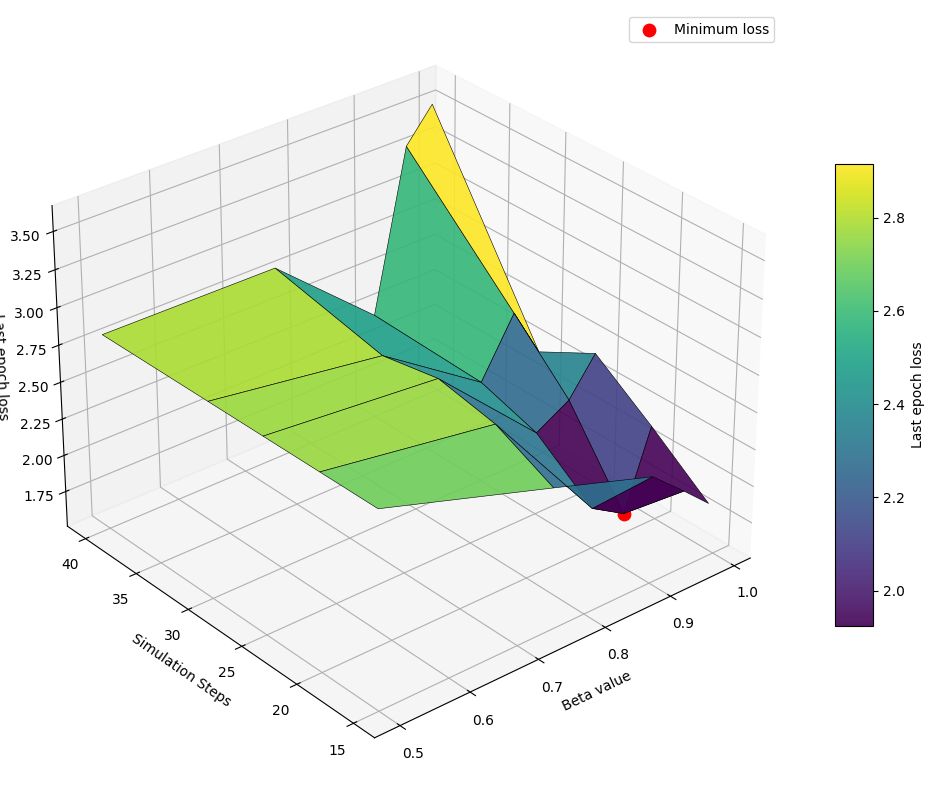

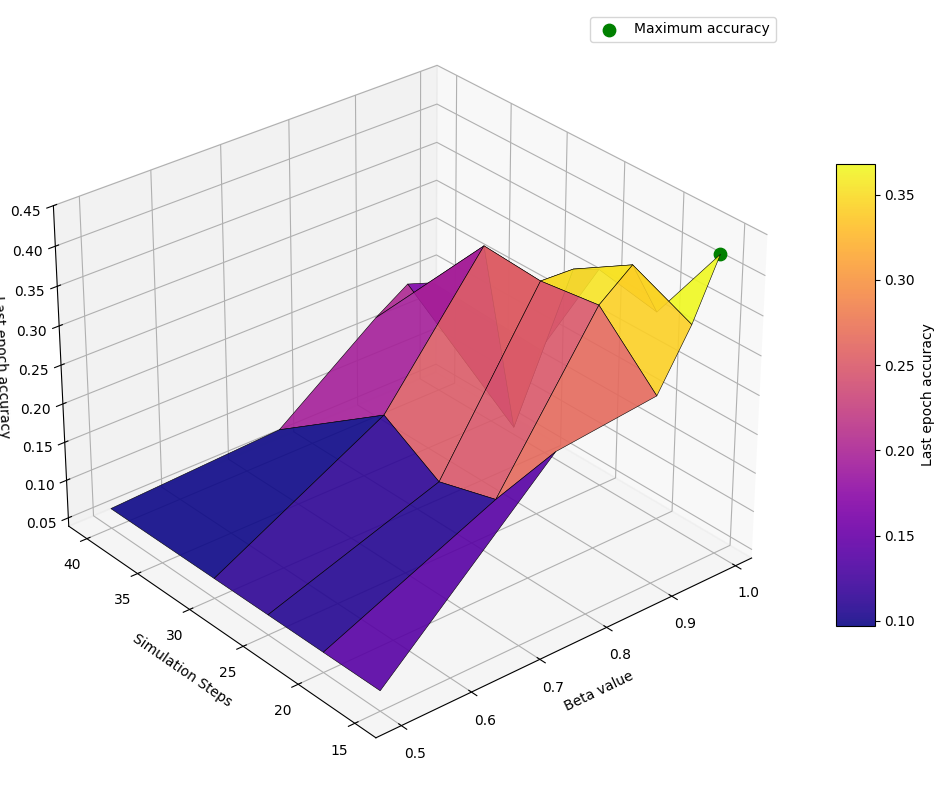

=== Best Parameter Combination (Minimum Last-Epoch Loss) ===
Beta: 0.95
Sim Steps: 20
Last Epoch Loss: 1.644256
File: upos_hypr-1_2026-05-02_16-36-17_e-5_s-20_spatial.json

=== Best Parameter Combination (Maximum Last-Epoch Accuracy) ===
Beta: 0.99
Sim Steps: 15
Last Epoch Accuracy: 0.424000
File: upos_hypr-1_2026-05-02_16-35-34_e-5_s-15_spatial.json


In [8]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob

# Build 3D surfaces of final-epoch metrics over (beta, sim_steps).
import numpy as np

files = sorted(glob('../output_results/E_pos/hypr-1/upos_hypr-1_*.json'))
if not files:
    raise FileNotFoundError('No matching files found')

# (beta, sim_steps, last_epoch_loss, last_epoch_accuracy, file_name, acc_key_used)
records = []
for file in files:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    training_config = data.get('training_config', {})
    results = data.get('results', {})

    beta_raw = training_config.get('beta')
    sim_steps_raw = training_config.get('sim_steps')
    epoch_losses = results.get('epoch_train_loss', [])
    series = results.get('epoch_train_accuracy', [])

    if beta_raw is None or sim_steps_raw is None or not epoch_losses or not series:
        continue

    beta = float(beta_raw)
    sim_steps = float(sim_steps_raw)
    last_epoch_loss = float(epoch_losses[-1])
    last_epoch_accuracy = float(series[-1])
    records.append((beta, sim_steps, last_epoch_loss, last_epoch_accuracy, Path(file).name, 'epoch_train_accuracy'))

if not records:
    raise ValueError(
        'No valid records found with beta, sim_steps, epoch_train_loss, and an accuracy series.'
    )

betas = sorted({r[0] for r in records})
sim_steps_vals = sorted({r[1] for r in records})

# Create rectangular grids for both surfaces.
X, Y = np.meshgrid(betas, sim_steps_vals)
Z_loss = np.full_like(X, np.nan, dtype=float)
Z_acc = np.full_like(X, np.nan, dtype=float)

for beta, sim_steps, loss, acc, _, _ in records:
    x_idx = betas.index(beta)
    y_idx = sim_steps_vals.index(sim_steps)
    Z_loss[y_idx, x_idx] = loss
    Z_acc[y_idx, x_idx] = acc

fig1 = plt.figure(figsize=(11, 8))
ax1 = fig1.add_subplot(111, projection='3d')
surface_loss = ax1.plot_surface(
    X, Y, Z_loss, cmap='viridis', edgecolor='k', linewidth=0.4, alpha=0.9
)
fig1.colorbar(surface_loss, ax=ax1, shrink=0.6, aspect=12, label='Last epoch loss')

best_beta, best_sim_steps, best_loss, _, best_loss_file, _ = min(records, key=lambda x: x[2])
ax1.scatter(best_beta, best_sim_steps, best_loss, color='red', s=80, label='Minimum loss')
ax1.legend()

ax1.set_xlabel('Beta value')
ax1.set_ylabel('Simulation Steps')
ax1.set_zlabel('Last epoch loss')
ax1.view_init(elev=30, azim=-130)
plt.tight_layout()
plt.show()

fig2 = plt.figure(figsize=(11, 8))
ax2 = fig2.add_subplot(111, projection='3d')
surface_acc = ax2.plot_surface(
    X, Y, Z_acc, cmap='plasma', edgecolor='k', linewidth=0.4, alpha=0.9
)
fig2.colorbar(surface_acc, ax=ax2, shrink=0.6, aspect=12, label='Last epoch accuracy')

best_beta_acc, best_sim_steps_acc, _, best_acc, best_acc_file, _ = max(records, key=lambda x: x[3])
ax2.scatter(best_beta_acc, best_sim_steps_acc, best_acc, color='green', s=80, label='Maximum accuracy')
ax2.legend()

ax2.set_xlabel('Beta value')
ax2.set_ylabel('Simulation Steps')
ax2.set_zlabel('Last epoch accuracy')
ax2.view_init(elev=30, azim=-130)
plt.tight_layout()
plt.show()

print('=== Best Parameter Combination (Minimum Last-Epoch Loss) ===')
print(f'Beta: {best_beta}')
print(f'Sim Steps: {best_sim_steps:g}')
print(f'Last Epoch Loss: {best_loss:.6f}')
print(f'File: {best_loss_file}')

print('\n=== Best Parameter Combination (Maximum Last-Epoch Accuracy) ===')
print(f'Beta: {best_beta_acc}')
print(f'Sim Steps: {best_sim_steps_acc:g}')
print(f'Last Epoch Accuracy: {best_acc:.6f}')
print(f'File: {best_acc_file}')

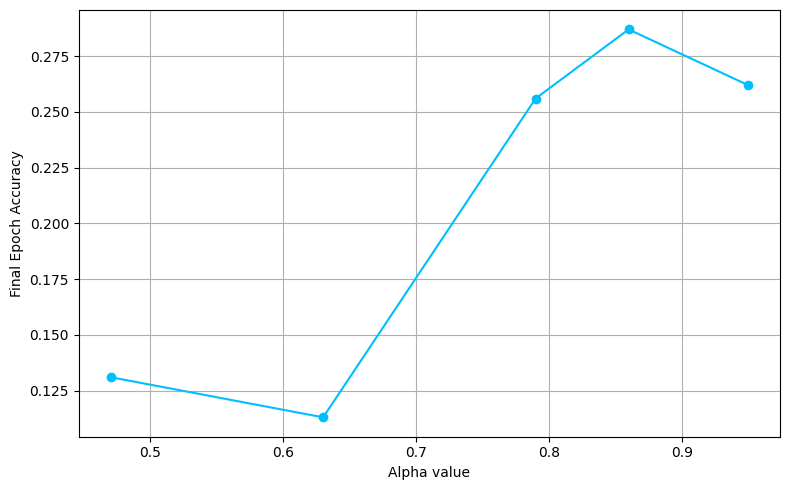

upos_hypr-2_2026-05-02_17-22-22_e-5_s-20_spatial.json: alpha=0.47  final_acc=0.131000
upos_hypr-2_2026-05-02_17-22-03_e-5_s-20_spatial.json: alpha=0.63  final_acc=0.113000
upos_hypr-2_2026-05-02_17-21-40_e-5_s-20_spatial.json: alpha=0.79  final_acc=0.256000
upos_hypr-2_2026-05-02_17-21-22_e-5_s-20_spatial.json: alpha=0.86  final_acc=0.287000
upos_hypr-2_2026-05-02_17-21-00_e-5_s-20_spatial.json: alpha=0.95  final_acc=0.262000


In [6]:
import json
from glob import glob
from pathlib import Path
import matplotlib.pyplot as plt

from colors import colors

# Read hypr-2 JSON files and collect (alpha, final_epoch_accuracy)
files = sorted(glob('../output_results/E_pos/hypr-2/upos_hypr-2_*.json'))
if not files:
    raise FileNotFoundError('No matching files found in hypr-2')

records = []  # (alpha, last_acc, filename, acc_key)
for file in files:
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    training_config = data.get('training_config', {})
    results = data.get('results', {})

    alpha_raw = training_config.get('alpha')
    if alpha_raw is None:
        continue

    series = results.get('epoch_train_accuracy')
    last_acc = float(series[-1])

    if last_acc is None:
        continue

    try:
        alpha = float(alpha_raw)
    except Exception:
        try:
            alpha = float(str(alpha_raw).strip())
        except Exception:
            continue

    records.append((alpha, last_acc, Path(file).name))

if not records:
    raise ValueError('No valid records found with alpha and an accuracy series in hypr-2 files.')

# Sort by alpha for plotting
records.sort(key=lambda x: x[0])
alphas = [r[0] for r in records]
accs = [r[1] for r in records]

plt.figure(figsize=(8,5))
plt.plot(alphas, accs, marker='o', linestyle='-', color=colors.trace_line)
plt.xlabel('Alpha value')
plt.ylabel('Final Epoch Accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()

# Print a small summary table
for alpha, acc, fname in records:
    print(f'{fname}: alpha={alpha}  final_acc={acc:.6f}')